#Function for splitting image into grid cells

In [1]:
import numpy as np

def split_into_grid_cells(image, grid_size=(8,8)):
    """
    Splits an image into grid cells (default 8x8).

    Input:
        image      : NumPy array (H×W×3 or H×W)
        grid_size  : (rows, cols)

    Output:
        cells      : list of cell images
        positions  : list of (row_index, col_index) for each cell
    """

    rows, cols = grid_size
    H, W = image.shape[:2]

    cell_h = H // rows
    cell_w = W // cols

    cells = []
    positions = []

    for r in range(rows):
        for c in range(cols):
            y1, y2 = r * cell_h, (r + 1) * cell_h
            x1, x2 = c * cell_w, (c + 1) * cell_w

            cell = image[y1:y2, x1:x2]
            cells.append(cell)
            positions.append((r, c))

    return cells, positions


#Feature Engineering
##All the following function take a cell as input



###Colour feature extraction


In [2]:
import cv2
import numpy as np
from skimage.measure import shannon_entropy

def extract_color_features(cell):
    """
    Extract handcrafted color features from a single image cell (e.g., 100x75).
    Returns a 1-D NumPy array of = 70 color-based features.

    [ hsv_hist values (17) ,
  RGB moments (9),
  color ratios (3),
  mean HSV (3),
  entropy (1),
  contrast (1),
  4x3 spatial HSV means (36) ]

    """

    # Ensure BGR → RGB and HSV conversions
    cell_rgb = cv2.cvtColor(cell, cv2.COLOR_BGR2RGB)
    cell_hsv = cv2.cvtColor(cell, cv2.COLOR_BGR2HSV)

    features = []

    # HSV Histograms (captures global color distribution) ---
    h_bins, s_bins, v_bins = 12, 4, 1
    hist_h = cv2.calcHist([cell_hsv], [0], None, [h_bins], [0, 180])
    hist_s = cv2.calcHist([cell_hsv], [1], None, [s_bins], [0, 256])
    hist_v = cv2.calcHist([cell_hsv], [2], None, [v_bins], [0, 256])
    hsv_hist = np.concatenate([hist_h, hist_s, hist_v]).flatten()
    hsv_hist = hsv_hist / np.sum(hsv_hist)            # normalize
    features.extend(hsv_hist.tolist())                # ≈ 17 features

    # Color Moments (mean, std, skew for each RGB channel) ---
    for i in range(3):
        ch = cell_rgb[:, :, i].ravel()
        mean = np.mean(ch)
        std = np.std(ch)
        skew = np.mean((ch - mean)**3) / (std**3 + 1e-8)
        features += [mean, std, skew]                 # 9 features total

    # Color Ratios (R/G, R/B, G/B) ---
    Rm, Gm, Bm = np.mean(cell_rgb[:, :, 0]), np.mean(cell_rgb[:, :, 1]), np.mean(cell_rgb[:, :, 2])
    eps = 1e-6
    features += [Rm / (Gm + eps), Rm / (Bm + eps), Gm / (Bm + eps)]

    # Mean HSV Values ---
    features += list(np.mean(cell_hsv.reshape(-1, 3), axis=0))

    # Entropy & Color Contrast ---
    ent = shannon_entropy(cell_hsv[:, :, 0])         # hue entropy
    contrast = float(np.max(cell_rgb) - np.min(cell_rgb))
    features += [ent, contrast]

    # Spatial Color Distribution (local means on 4x3 grid) ---
    h_step = cell.shape[0] // 4
    w_step = cell.shape[1] // 3
    local_means = []
    for i in range(4):
        for j in range(3):
            sub = cell_hsv[i*h_step:(i+1)*h_step, j*w_step:(j+1)*w_step]
            local_means.extend(np.mean(sub.reshape(-1, 3), axis=0))
    features.extend(local_means)                     # 12×3 = 36 features

    # Normalize to [0,1] range for stability ---
    feats = np.array(features, dtype=np.float32)
    if np.max(feats) != 0:
        feats = (feats - np.min(feats)) / (np.max(feats) - np.min(feats))

    return feats

###Texture Feature Extraction

In [3]:
import numpy as np
import cv2
from skimage import color, feature, filters
from scipy import ndimage
import pywt

def extract_texture_features(cell):
    """
    Extracts ~91 texture features using Gabor, LBP, Laplacian variance, wavelets.

    24 (Gabor)
+ 58 (LBP)
+ 1 (Laplacian)
+ 8 (Wavelets)
= 91 features per cell

    """

    # Convert to grayscale
    if cell.ndim == 3:
        cell_gray = color.rgb2gray(cell)
    else:
        cell_gray = cell.copy()

    cell_gray = cell_gray.astype(np.float32)
    if cell_gray.max() > 1.0:
        cell_gray /= 255.0

    feats = []

    # 1) Gabor Features (same as before, best available)
    frequencies = [0.1, 0.2, 0.3]
    thetas = [0, np.pi/4, np.pi/2, 3*np.pi/4]

    for freq in frequencies:
        for theta in thetas:
            # Use skimage.filters.gabor instead of scipy.ndimage.gabor_filter
            real, imag = filters.gabor(cell_gray, frequency=freq, theta=theta)
            magnitude = np.sqrt(real**2 + imag**2)
            feats.append(magnitude.mean())
            feats.append(magnitude.var())

    # 2) Local Binary Pattern
    lbp = feature.local_binary_pattern(cell_gray, P=8, R=1, method="uniform")
    lbp_hist, _ = np.histogram(lbp.ravel(), bins=np.arange(0, 59))
    lbp_hist = lbp_hist.astype("float")
    lbp_hist /= (lbp_hist.sum() + 1e-6)
    feats.extend(lbp_hist.tolist())

    # 3) Laplacian Variance (replaces rank entropy, fast computation)
    lap = cv2.Laplacian((cell_gray*255).astype(np.uint8), cv2.CV_64F)
    lap_var = lap.var()
    feats.append(lap_var)

    # 4) Wavelet Coefficients (pywt)
    coeffs2 = pywt.dwt2(cell_gray, 'db2')
    LL, (LH, HL, HH) = coeffs2
    wavelet_feats = [
        LL.mean(), LH.mean(), HL.mean(), HH.mean(),
        LL.var(), LH.var(), HL.var(), HH.var()
    ]
    feats.extend(wavelet_feats)

    return np.array(feats, dtype=np.float32)

###Edge Feature Extraction

In [4]:
import numpy as np
from skimage.feature import hog
from skimage.measure import label, regionprops
from skimage import color
import cv2

def extract_edge_shape_features(cell):
    """
    Extract ~38 edge & shape features from one image cell.

    36 (HOG)
+ 1 (Sobel density)
+ 1 (Canny density)
+ 1 (Contour ratio)
= 39 features per cell

    """

    # 1) Convert to grayscale
    if cell.ndim == 3:
        gray = color.rgb2gray(cell)
    else:
        gray = cell.copy()

    gray = gray.astype(np.float32)
    if gray.max() > 1.0:
        gray /= 255.0

    # 2) HOG features
    hog_features = hog(
        gray,
        pixels_per_cell=(32, 32),
        cells_per_block=(1, 1),
        orientations=6,
        feature_vector=True
    )

    # 3) Edge magnitude using Sobel
    sobelx = cv2.Sobel(gray, cv2.CV_32F, 1, 0, ksize=3)
    sobely = cv2.Sobel(gray, cv2.CV_32F, 0, 1, ksize=3)
    sobel_mag = np.sqrt(sobelx**2 + sobely**2)

    edge_density = float(np.mean(sobel_mag > 0.1))

    # 4)Canny edges
    canny_edges = cv2.Canny((gray*255).astype(np.uint8), 60, 120)
    canny_density = np.mean(canny_edges > 0)

    # 5) Contour / connected edge structure
    _, binary_thresh = cv2.threshold((sobel_mag*255).astype(np.uint8),
                                     np.percentile(sobel_mag, 75), 255,
                                     cv2.THRESH_BINARY)

    labeled = label(binary_thresh > 0)

    largest_area = 0
    for region in regionprops(labeled):
        largest_area = max(largest_area, region.area)

    cell_area = gray.shape[0] * gray.shape[1]
    contour_ratio = largest_area / cell_area if cell_area > 0 else 0

    # Combine final vector
    return np.hstack((
        hog_features,     # ~36
        [edge_density],   # 1
        [canny_density],  # 1 (new, useful)
        [contour_ratio]   # 1
    )).astype(np.float32)



###Context Feature extraction

In [5]:
import numpy as np
from skimage.feature import corner_harris, corner_peaks
import cv2

def extract_context_features(cell, row, col, grid_size=(8,8)):
    """
    Context/Objectness features (~6 features per cell)

    [
  harris_keypoint_count,
  saliency_score,
  row_norm,
  col_norm,
  neighbor_edge_mean,
  neighbor_saliency_mean
  6 features
]
    """

    # ---- Convert to grayscale ----
    if cell.ndim == 3:
        gray = cv2.cvtColor(cell.astype(np.float32), cv2.COLOR_RGB2GRAY)
    else:
        gray = cell.astype(np.float32)

    # Normalize to [0,1]
    if gray.max() > 1.0:
        gray /= 255.0

    # 1) Harris Corner Keypoint Count
    harris_resp = corner_harris(gray)
    keypoints = corner_peaks(harris_resp, min_distance=3, threshold_rel=0.01)
    keypoint_count = len(keypoints)

    # 2) Saliency Score (blur difference)
    blur = cv2.GaussianBlur(gray, (5,5), 3)  # fast blur
    saliency_map = np.abs(gray - blur)
    saliency_score = float(np.mean(saliency_map))

    # 3) Normalized Grid Coordinates
    rows, cols = grid_size
    row_norm = row / (rows - 1)
    col_norm = col / (cols - 1)

    # 4) Neighbor Context Placeholders
    neighbor_edge_mean = 0.0
    neighbor_saliency_mean = 0.0

    return np.array([
        keypoint_count,
        saliency_score,
        row_norm,
        col_norm,
        neighbor_edge_mean,
        neighbor_saliency_mean
    ], dtype=np.float32)


##Given a cell as input , gives out all the 206 features

In [6]:
import numpy as np

def extract_all_cell_features(cell, row, col, grid_size=(8,8)):
    """
    Extract all ~206 features from a single image cell.

    Inputs:
        cell      -> image patch (RGB)
        row, col  -> grid coordinates (0-7)
        grid_size -> default (8,8)

    Output:
        feature_vector: 1D NumPy array (~206 features)
    """

    # ---- Extract each feature category ----
    color_feats   = extract_color_features(cell)          # ~70
    texture_feats = extract_texture_features(cell)        # ~91
    edge_feats    = extract_edge_shape_features(cell)     # ~39
    context_feats = extract_context_features(cell, row, col, grid_size)  # ~6

    # ---- Concatenate ----
    feature_vector = np.hstack([
        color_feats,
        texture_feats,
        edge_feats,
        context_feats
    ]).astype(np.float32)

    return feature_vector


##Drive Mounting

In [7]:
from google.colab import drive
import os

# Step 1: Mount Google Drive
drive.mount('/content/drive')

# Step 2: Correct path to your dataset folder
data_path = "/content/drive/MyDrive/DS203 Processed"

# Step 3: Verify that it’s accessible
if os.path.exists(data_path):
    print("✅ Folder found! Listing contents:\n")
    print(os.listdir(data_path))
else:
    print("⚠️ Folder not found. Double-check the path or spacing.")
    print("Try running: os.listdir('/content/drive/MyDrive')")


Mounted at /content/drive
✅ Folder found! Listing contents:

['10.jpg', '5.jpg', '6.jpg', '3.jpg', '2.jpg', '1.jpg', '8.jpg', '15.jpg', '7.jpg', '17.jpg', '14.jpg', '12.jpg', '4.jpg', '16.jpg', '11.jpg', '9.jpg', '13.jpg', '18.jpg', '22.jpg', '23.jpg', '26.jpg', '30.jpg', '20.jpg', '24.jpg', '21.jpg', '28.jpg', '19.jpg', '31.jpg', '25.jpg', '27.jpg', '29.jpg', '34.jpg', '32.jpg', '39.jpg', '37.jpg', '36.jpg', '35.jpg', '38.jpg', '33.jpg', '41.jpg', '47.jpg', '49.jpg', '44.jpg', '48.jpg', '43.jpg', '40.jpg', '46.jpg', '42.jpg', '45.jpg', '53.jpg', '55.jpg', '56.jpg', '58.jpg', '57.jpg', '51.jpg', '52.jpg', '50.jpg', '54.jpg', '59.jpg', '60.jpg', '63.jpg', '64.jpg', '61.jpg', '65.jpg', '66.jpg', '62.jpg', '73.jpg', '70.jpg', '69.jpg', '68.jpg', '71.jpg', '77.jpg', '72.jpg', '79.jpg', '74.jpg', '75.jpg', '67.jpg', '78.jpg', '76.jpg', '90.jpg', '84.jpg', '82.jpg', '92.jpg', '91.jpg', '88.jpg', '83.jpg', '85.jpg', '89.jpg', '87.jpg', '80.jpg', '81.jpg', '86.jpg', '106.jpg', '94.jpg', '97.jp

In [8]:
import os

folder =  "/content/drive/MyDrive/DS203 Processed"

files = os.listdir(folder)
print("Total files:", len(files))
print("Sample filenames:", files[:20])


Total files: 431
Sample filenames: ['10.jpg', '5.jpg', '6.jpg', '3.jpg', '2.jpg', '1.jpg', '8.jpg', '15.jpg', '7.jpg', '17.jpg', '14.jpg', '12.jpg', '4.jpg', '16.jpg', '11.jpg', '9.jpg', '13.jpg', '18.jpg', '22.jpg', '23.jpg']


## The code below takes in the image dataset -> converts it into grid cells - > extracts the required features

In [10]:
import os
import cv2
import numpy as np
import pandas as pd
from google.colab import files  # for downloading in Colab

# -------- CONFIG --------
IMG_FOLDER = "/content/drive/MyDrive/DS203 Processed"
LABEL_FILE = "/content/data ds project.csv"

GRID_SIZE = (8, 8)
FEATURE_SIZE = 206  # number of features per cell

# -------- LOAD LABELS --------
labels_df = pd.read_csv("labels.csv")

X, y, meta = [], [], []
image_index = 0

for idx, row in labels_df.iterrows():
    img_name = row["image_name"]
    label_values = row.iloc[1:].values.astype(int)   # 64 labels (0/1)

    img_path = os.path.join(IMG_FOLDER, img_name)
    img = cv2.imread(img_path)

    if img is None:
        print(f"⚠️ Image not found: {img_name}, skipping...")
        continue

    cells, positions = split_into_grid_cells(img, GRID_SIZE)

    if len(cells) != 64:
        print(f"⚠️ {img_name} didn't split into 64 cells, skipping...")
        continue

    for cell_idx, cell in enumerate(cells):
        row_pos, col_pos = positions[cell_idx]
        features = extract_all_cell_features(cell, row_pos, col_pos, GRID_SIZE)

        if len(features) != FEATURE_SIZE:
            print(f"⚠️ Feature length mismatch in {img_name}, cell {cell_idx}, skipping...")
            continue

        X.append(features)
        y.append(label_values[cell_idx])
        meta.append([image_index, cell_idx])

    image_index += 1
    print(f"✅ Processed {img_name} | Total images: {image_index}")

# -------- CONVERT TO NUMPY --------
X = np.array(X, dtype=np.float32)
y = np.array(y, dtype=np.int32)

print("✅ Dataset Built")
print("X shape:", X.shape)
print("y shape:", y.shape)

# -------- SAVE TO .NPY --------
np.save("/content/drive/MyDrive/DS203 Processed/X_cells.npy", X)
np.save("/content/drive/MyDrive/DS203 Processed/y_cells.npy", y)

# -------- SAVE TO .CSV --------
df = pd.DataFrame(X, columns=[f"feature_{i+1}" for i in range(X.shape[1])])
df.insert(0, "cell_number", [m[1] for m in meta])
df.insert(0, "image_number", [m[0] for m in meta])
df["label"] = y

csv_path = "/content/cell_features.csv"
df.to_csv(csv_path, index=False)
print(f"💾 CSV saved to {csv_path}")

# -------- DOWNLOAD CSV --------
files.download(csv_path)
print("⬇️ CSV download started...")


/usr/local/lib/python3.12/dist-packages/skimage/feature/texture.py:385: UserWarning: Applying `local_binary_pattern` to floating-point images may give unexpected results when small numerical differences between adjacent pixels are present. It is recommended to use this function with images of integer dtype.
  warnings.warn(


✅ Processed 1.jpg | Total images: 1
✅ Processed 10.jpg | Total images: 2
✅ Processed 100.jpg | Total images: 3
✅ Processed 101.jpg | Total images: 4
✅ Processed 103.jpg | Total images: 5
✅ Processed 104.jpg | Total images: 6
✅ Processed 105.jpg | Total images: 7
✅ Processed 106.jpg | Total images: 8
✅ Processed 107.jpg | Total images: 9
✅ Processed 108.jpg | Total images: 10
✅ Processed 109.jpg | Total images: 11
✅ Processed 11.jpg | Total images: 12
✅ Processed 110.jpg | Total images: 13
✅ Processed 111.jpg | Total images: 14
✅ Processed 112.jpg | Total images: 15
✅ Processed 113.jpg | Total images: 16
✅ Processed 114.jpg | Total images: 17
✅ Processed 115.jpg | Total images: 18
✅ Processed 116.jpg | Total images: 19
✅ Processed 117.jpg | Total images: 20
✅ Processed 118.jpg | Total images: 21
✅ Processed 119.jpg | Total images: 22
✅ Processed 12.jpg | Total images: 23
✅ Processed 120.jpg | Total images: 24
✅ Processed 121.jpg | Total images: 25
✅ Processed 122.jpg | Total images: 26


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

⬇️ CSV download started...


In [11]:
import numpy as np

X = np.load("/content/drive/MyDrive/DS203 Processed/X_cells.npy")
y = np.load("/content/drive/MyDrive/DS203 Processed/y_cells.npy")

#Train test split

In [20]:
import pandas as pd
from sklearn.model_selection import train_test_split
from google.colab import files  # for downloading

# -------- LOAD CSV --------
csv_path = "/content/drive/MyDrive/DS203 Processed/cell_features.csv"
df = pd.read_csv(csv_path)

# -------- SPLIT BY IMAGE NUMBER --------
image_numbers = df["image_number"].unique()
train_images, test_images = train_test_split(
    image_numbers, test_size=0.2, random_state=42
)

train_df = df[df["image_number"].isin(train_images)].reset_index(drop=True)
test_df = df[df["image_number"].isin(test_images)].reset_index(drop=True)

# -------- FEATURES AND LABELS --------
feature_cols = [col for col in df.columns if "feature_" in col] # Extract feature column names
X_train = train_df[feature_cols]
y_train = train_df["label"]

X_test = test_df[feature_cols]
y_test = test_df["label"]

# -------- SAVE SPLITS TO CSV --------
X_train_path = "/content/X_train.csv"
X_test_path = "/content/X_test.csv"
y_train_path = "/content/y_train.csv"
y_test_path = "/content/y_test.csv"

X_train.to_csv(X_train_path, index=False)
X_test.to_csv(X_test_path, index=False)
y_train.to_csv(y_train_path, index=False)
y_test.to_csv(y_test_path, index=False)

print("✅ Train/Test splits saved successfully!")

# -------- DOWNLOAD CSV FILES (Colab) --------
files.download(X_train_path)
files.download(X_test_path)
files.download(y_train_path)
files.download(y_test_path)
print("⬇️ Download started for all CSV files.")

✅ Train/Test splits saved successfully!


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

⬇️ Download started for all CSV files.


#PCA on the training data

Original feature count: 206
Reduced PCA feature count: 51
💾 PCA-transformed datasets saved successfully!


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

⬇️ CSV download started!


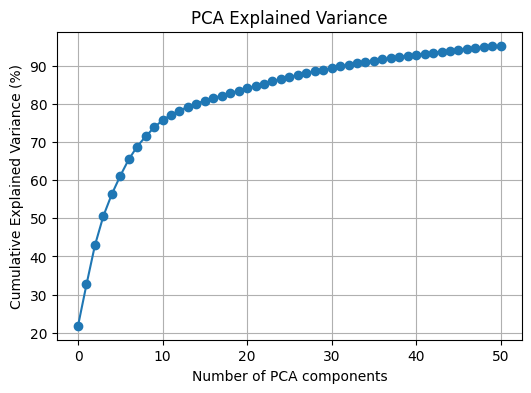

In [22]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
import pandas as pd
import numpy as np
from google.colab import files  # for download
import matplotlib.pyplot as plt # Import matplotlib

# --- 1) Scale input features (recommended before PCA) ---
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)   # fit on train only
X_test_scaled  = scaler.transform(X_test)        # transform test the same way

# --- 2) Fit PCA on TRAIN only ---
pca = PCA(n_components=0.95)  # keep 95% variance OR set fixed, e.g., 50
X_train_pca = pca.fit_transform(X_train_scaled)
X_test_pca  = pca.transform(X_test_scaled)

print("Original feature count:", X_train.shape[1])
print("Reduced PCA feature count:", X_train_pca.shape[1])

# --- 3) Save PCA-transformed datasets ---
# Save as CSV
X_train_pca_csv = "/content/X_train_pca.csv"
X_test_pca_csv  = "/content/X_test_pca.csv"

pd.DataFrame(X_train_pca).to_csv(X_train_pca_csv, index=False)
pd.DataFrame(X_test_pca).to_csv(X_test_pca_csv, index=False)

# Save as NPY (optional)
np.save("/content/X_train_pca.npy", X_train_pca)
np.save("/content/X_test_pca.npy", X_test_pca)

print("💾 PCA-transformed datasets saved successfully!")

# --- 4) Download CSV files in Colab ---
files.download(X_train_pca_csv)
files.download(X_test_pca_csv)
print("⬇️ CSV download started!")

# ---------- PCA explained variance plot ----------
plt.figure(figsize=(6,4))
plt.plot(np.cumsum(pca.explained_variance_ratio_)*100, marker='o')
plt.xlabel("Number of PCA components")
plt.ylabel("Cumulative Explained Variance (%)")
plt.title("PCA Explained Variance")
plt.grid(True)
plt.show()

#Code for saving PCA transform

In [23]:
import joblib

# Save scaler, PCA, and model
joblib.dump(scaler, "scaler.pkl")
joblib.dump(pca, "pca.pkl")
print("Saved scaler, PCA")


Saved scaler, PCA


#Code to Load Later

In [24]:
import joblib

scaler = joblib.load("scaler.pkl")
pca = joblib.load("pca.pkl")


## Code for Training different classification models (Can change the models if we want)

#Chooses best model and saves it


--- Evaluating Logistic Regression ---
[TEST] Acc=0.7624, Prec=0.7088, Rec=0.6404, F1=0.6543, AUC=0.8013
[TRAIN] Acc=0.7726, Prec=0.7164, Rec=0.6535, F1=0.6692, AUC=0.8101


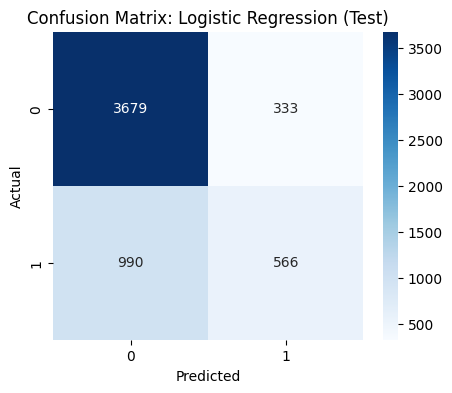

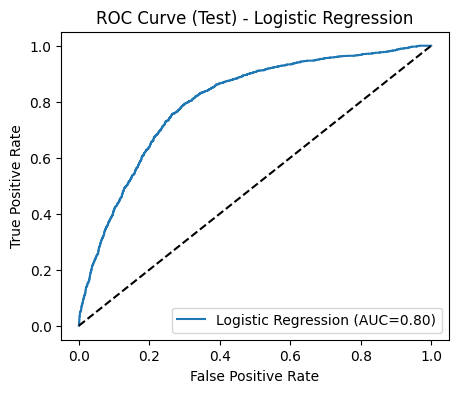


--- Evaluating Random Forest ---
[TEST] Acc=0.8181, Prec=0.8044, Rec=0.7152, F1=0.7397, AUC=0.8683
[TRAIN] Acc=1.0000, Prec=1.0000, Rec=1.0000, F1=1.0000, AUC=1.0000


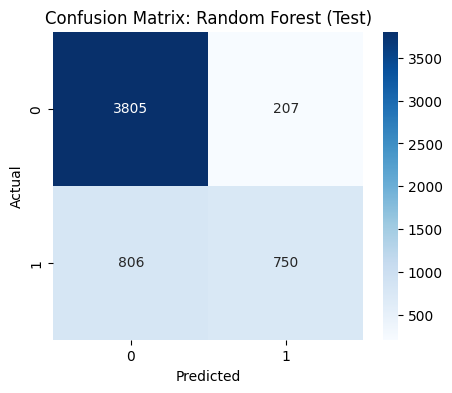

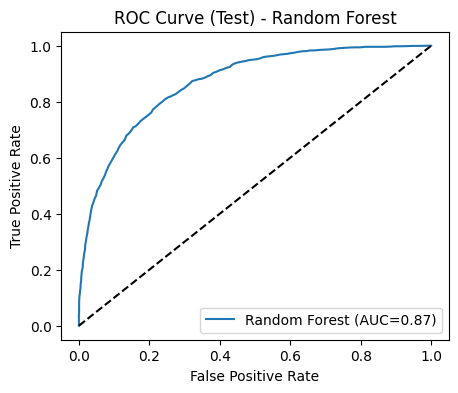


--- Evaluating MLP (20) ---
[TEST] Acc=0.8551, Prec=0.8240, Rec=0.8089, F1=0.8159, AUC=0.9089
[TRAIN] Acc=0.8988, Prec=0.8783, Rec=0.8614, F1=0.8692, AUC=0.9501


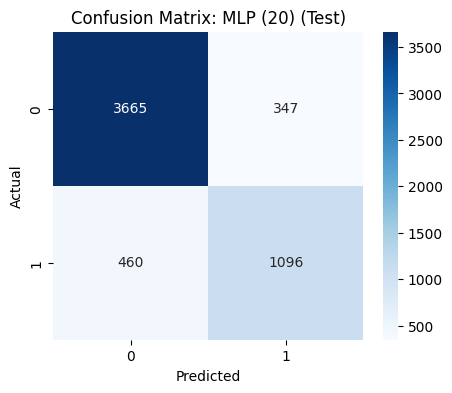

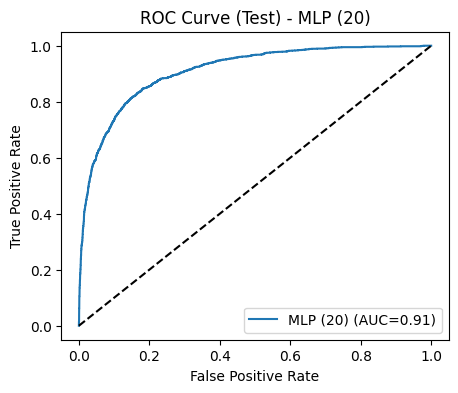


--- Evaluating XGBoost ---


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:199: UserWarning: [21:47:41] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


[TEST] Acc=0.8429, Prec=0.8190, Rec=0.7731, F1=0.7907, AUC=0.9046
[TRAIN] Acc=0.9188, Prec=0.9124, Rec=0.8781, F1=0.8932, AUC=0.9681


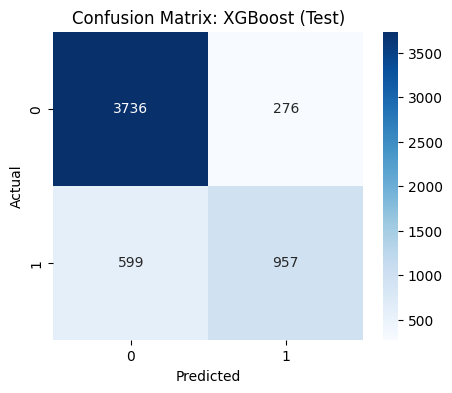

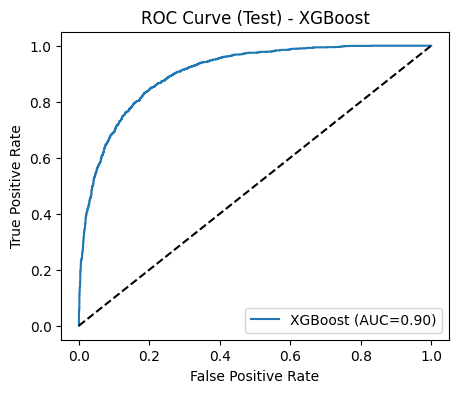


Model Comparison:

                 Model  Train_Acc  Train_Prec  Train_Rec  Train_F1  Train_AUC  \
0  Logistic Regression   0.772620    0.716387   0.653515  0.669151   0.810132   
1        Random Forest   1.000000    1.000000   1.000000  1.000000   1.000000   
2             MLP (20)   0.898755    0.878307   0.861356  0.869246   0.950095   
3              XGBoost   0.918832    0.912444   0.878074  0.893178   0.968097   

   Test_Acc  Test_Prec  Test_Rec   Test_F1  Test_AUC  
0  0.762392   0.708776  0.640376  0.654349  0.801275  
1  0.818068   0.804450  0.715205  0.739710  0.868321  
2  0.855065   0.824007  0.808940  0.815867  0.908949  
3  0.842852   0.818989  0.773122  0.790720  0.904607  


/tmp/ipython-input-1161212223.py:125: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="Test_F1", y="Model", data=df_results.sort_values("Test_F1", ascending=False), palette="viridis")


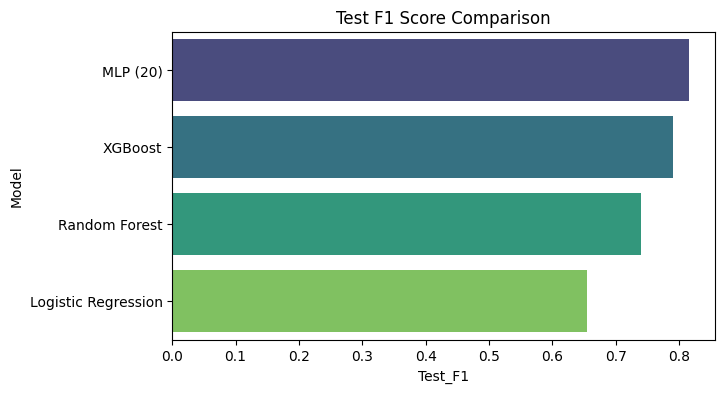

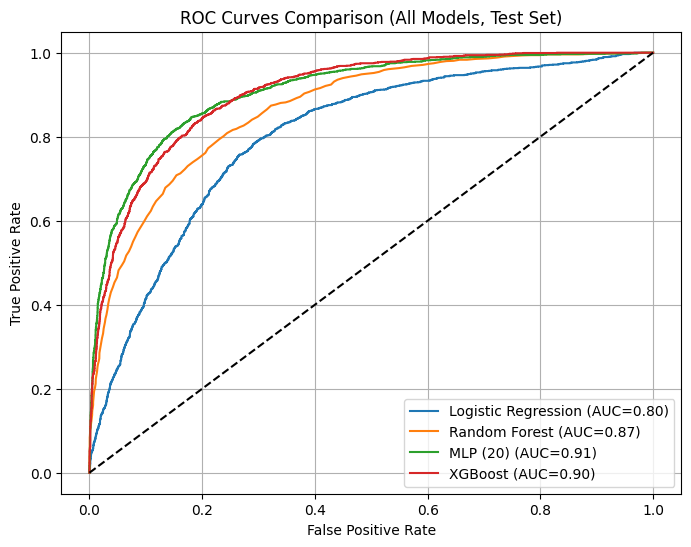

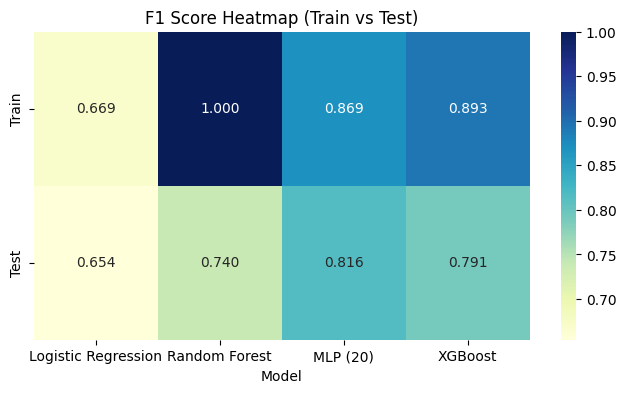


✅ Best Model Saved: MLP (20) (Test F1=0.8159) → wildlife_model.pkl


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix, roc_curve, auc
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.neural_network import MLPClassifier
from xgboost import XGBClassifier

results = []
best_model = None
best_f1 = -1.0
best_name = None

# ---------- Updated Evaluation Function ----------
def evaluate_model(name, model, X_train, y_train, X_test, y_test, compute_train_metrics=True):
    global best_model, best_f1, best_name

    print(f"\n--- Evaluating {name} ---")
    model.fit(X_train, y_train)
    y_test_pred = model.predict(X_test)
    y_train_pred = model.predict(X_train) if compute_train_metrics else None

    # Probabilities for AUC / ROC
    y_test_proba = model.predict_proba(X_test)[:,1] if hasattr(model, "predict_proba") else None
    y_train_proba = model.predict_proba(X_train)[:,1] if (compute_train_metrics and hasattr(model, "predict_proba")) else None

    # ---------- Test Metrics ----------
    test_acc = accuracy_score(y_test, y_test_pred)
    test_prec = precision_score(y_test, y_test_pred, average="macro", zero_division=0)
    test_rec = recall_score(y_test, y_test_pred, average="macro", zero_division=0)
    test_f1 = f1_score(y_test, y_test_pred, average="macro", zero_division=0)
    test_rocauc = roc_auc_score(y_test, y_test_proba) if y_test_proba is not None else None

    print(f"[TEST] Acc={test_acc:.4f}, Prec={test_prec:.4f}, Rec={test_rec:.4f}, F1={test_f1:.4f}, "
          f"AUC={test_rocauc:.4f}" if test_rocauc else f"[TEST] Acc={test_acc:.4f}, F1={test_f1:.4f}")

    # ---------- Train Metrics ----------
    if compute_train_metrics:
        train_acc = accuracy_score(y_train, y_train_pred)
        train_prec = precision_score(y_train, y_train_pred, average="macro", zero_division=0)
        train_rec = recall_score(y_train, y_train_pred, average="macro", zero_division=0)
        train_f1 = f1_score(y_train, y_train_pred, average="macro", zero_division=0)
        train_rocauc = roc_auc_score(y_train, y_train_proba) if y_train_proba is not None else None

        print(f"[TRAIN] Acc={train_acc:.4f}, Prec={train_prec:.4f}, Rec={train_rec:.4f}, F1={train_f1:.4f}, "
              f"AUC={train_rocauc:.4f}" if train_rocauc else f"[TRAIN] Acc={train_acc:.4f}, F1={train_f1:.4f}")

    # ---------- Confusion Matrix for Test ----------
    cm = confusion_matrix(y_test, y_test_pred)
    plt.figure(figsize=(5,4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.title(f'Confusion Matrix: {name} (Test)')
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()

    # ---------- ROC Curve for Test ----------
    if y_test_proba is not None:
        fpr, tpr, _ = roc_curve(y_test, y_test_proba)
        plt.figure(figsize=(5,4))
        plt.plot(fpr, tpr, label=f'{name} (AUC={test_rocauc:.2f})')
        plt.plot([0,1], [0,1], 'k--')
        plt.xlabel("False Positive Rate")
        plt.ylabel("True Positive Rate")
        plt.title(f"ROC Curve (Test) - {name}")
        plt.legend()
        plt.show()

    # ---------- Track best model ----------
    if test_f1 > best_f1:  # still based on test F1
        best_f1 = test_f1
        best_model = model
        best_name = name

    # Return metrics
    return {
        "train": {"acc": train_acc, "prec": train_prec, "rec": train_rec, "f1": train_f1, "rocauc": train_rocauc} if compute_train_metrics else None,
        "test": {"acc": test_acc, "prec": test_prec, "rec": test_rec, "f1": test_f1, "rocauc": test_rocauc}
    }

# ---------- Models ----------
models = [
    ("Logistic Regression", LogisticRegression(max_iter=2000)),
    ("Random Forest", RandomForestClassifier(n_estimators=200, random_state=42)),
    ("MLP (20)", MLPClassifier(hidden_layer_sizes=(20,), max_iter=2000, random_state=42)),
    ("XGBoost", XGBClassifier(
        n_estimators=300,
        learning_rate=0.05,
        max_depth=5,
        subsample=0.8,
        colsample_bytree=0.8,
        eval_metric='logloss',
        use_label_encoder=False
    ))
]

# ---------- Evaluate ----------
all_results = []
roc_curves = {}  # store ROC curves for plotting together
for name, model in models:
    metrics = evaluate_model(name, model, X_train_pca, y_train, X_test_pca, y_test)
    all_results.append([name,
                        metrics["train"]["acc"], metrics["train"]["prec"], metrics["train"]["rec"], metrics["train"]["f1"], metrics["train"]["rocauc"],
                        metrics["test"]["acc"], metrics["test"]["prec"], metrics["test"]["rec"], metrics["test"]["f1"], metrics["test"]["rocauc"]
                       ])
    # Store ROC for combined plot
    if hasattr(model, "predict_proba"):
        y_proba = model.predict_proba(X_test_pca)[:,1]
        fpr, tpr, _ = roc_curve(y_test, y_proba)
        roc_curves[name] = (fpr, tpr, metrics["test"]["rocauc"])

# ---------- Summary Table ----------
df_results = pd.DataFrame(all_results,
                          columns=["Model",
                                   "Train_Acc","Train_Prec","Train_Rec","Train_F1","Train_AUC",
                                   "Test_Acc","Test_Prec","Test_Rec","Test_F1","Test_AUC"])
print("\nModel Comparison:\n")
print(df_results)

# ---------- Bar Plot for Test F1 ----------
plt.figure(figsize=(7,4))
sns.barplot(x="Test_F1", y="Model", data=df_results.sort_values("Test_F1", ascending=False), palette="viridis")
plt.title("Test F1 Score Comparison")
plt.show()

# ---------- Combined ROC Curve Plot ----------
plt.figure(figsize=(8,6))
for name, (fpr, tpr, roc_auc) in roc_curves.items():
    plt.plot(fpr, tpr, label=f"{name} (AUC={roc_auc:.2f})")
plt.plot([0,1],[0,1],'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves Comparison (All Models, Test Set)")
plt.legend()
plt.grid(True)
plt.show()

# ---------- Heatmap of F1 Scores ----------
f1_data = {
    "Train": df_results["Train_F1"].values,
    "Test": df_results["Test_F1"].values
}
f1_df = pd.DataFrame(f1_data, index=df_results["Model"]).T

plt.figure(figsize=(8,4))
sns.heatmap(f1_df, annot=True, fmt=".3f", cmap="YlGnBu")
plt.title("F1 Score Heatmap (Train vs Test)")
plt.show()

# ---------- Save Best Model ----------
if best_model is not None:
    joblib.dump(best_model, "wildlife_model.pkl")
    print(f"\n✅ Best Model Saved: {best_name} (Test F1={best_f1:.4f}) → wildlife_model.pkl")


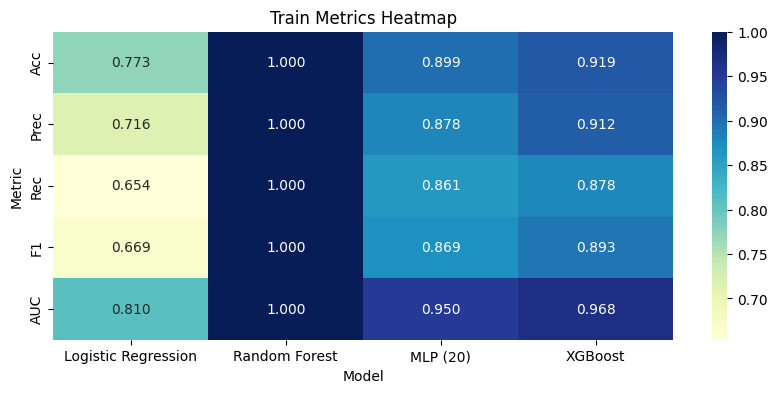

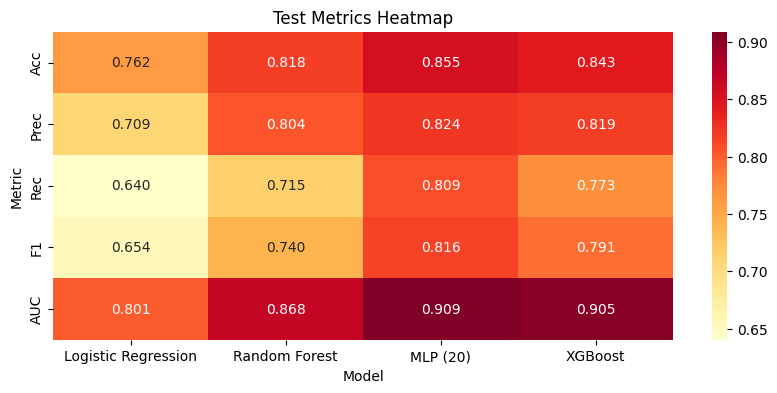

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

metrics_list = ["Acc", "Prec", "Rec", "F1", "AUC"]

# Prepare heatmap data for train and test
train_data = df_results[["Train_Acc","Train_Prec","Train_Rec","Train_F1","Train_AUC"]].copy()
train_data.index = df_results["Model"]
train_data.columns = metrics_list

test_data = df_results[["Test_Acc","Test_Prec","Test_Rec","Test_F1","Test_AUC"]].copy()
test_data.index = df_results["Model"]
test_data.columns = metrics_list

# ---------- Heatmap for Train Metrics ----------
plt.figure(figsize=(10,4))
sns.heatmap(train_data.T, annot=True, fmt=".3f", cmap="YlGnBu")
plt.title("Train Metrics Heatmap")
plt.xlabel("Model")
plt.ylabel("Metric")
plt.show()

# ---------- Heatmap for Test Metrics ----------
plt.figure(figsize=(10,4))
sns.heatmap(test_data.T, annot=True, fmt=".3f", cmap="YlOrRd")
plt.title("Test Metrics Heatmap")
plt.xlabel("Model")
plt.ylabel("Metric")
plt.show()


#Visualisation

In [ ]:
import os
import cv2
import pandas as pd
import numpy as np
from google.colab import files
import joblib

# ---------- CONFIG ----------
IMG_FOLDER = "/content/drive/MyDrive/DS203 Processed"   # original images
OUTPUT_TRAIN_IMG_FOLDER = "/content/predicted_images_train"
OUTPUT_TEST_IMG_FOLDER  = "/content/predicted_images_test"
OUTPUT_TRAIN_CSV_FOLDER = "/content/predicted_csvs_train"
OUTPUT_TEST_CSV_FOLDER  = "/content/predicted_csvs_test"

for folder in [OUTPUT_TRAIN_IMG_FOLDER, OUTPUT_TEST_IMG_FOLDER, OUTPUT_TRAIN_CSV_FOLDER, OUTPUT_TEST_CSV_FOLDER]:
    os.makedirs(folder, exist_ok=True)

# ---------- LOAD BEST MODEL, SCALER, PCA ----------
best_model = joblib.load("wildlife_model.pkl")
scaler = joblib.load("scaler.pkl")
pca = joblib.load("pca.pkl")

# ---------- LOAD CELL FEATURES ----------
cell_features_csv = "/content/drive/MyDrive/DS203 Processed/cell_features.csv"
df = pd.read_csv(cell_features_csv)

# ---------- SPLIT TRAIN / TEST IMAGE NUMBERS ----------
train_images = df["image_number"].unique()[:int(0.8*len(df["image_number"].unique()))]  # use same split as before
test_images  = df["image_number"].unique()[int(0.8*len(df["image_number"].unique())):]

def predict_and_save(image_numbers, img_folder, out_img_folder, out_csv_folder):
    for image_number in image_numbers:
        img_df = df[df["image_number"] == image_number].reset_index(drop=True)
        cells = img_df[["cell_number"] + [c for c in img_df.columns if "feature_" in c]]

        # Extract features and apply scaler + PCA
        X_img = cells.drop(columns=["cell_number"]).values
        X_img_scaled = scaler.transform(X_img)
        X_img_pca = pca.transform(X_img_scaled)

        # Predict labels
        y_pred = best_model.predict(X_img_pca)

        # Save CSV
        csv_out = pd.DataFrame({
            "cell_number": cells["cell_number"],
            "predicted_label": y_pred
        })
        csv_path = os.path.join(out_csv_folder, f"image_{image_number}_pred.csv")
        csv_out.to_csv(csv_path, index=False)

        # Load original image
        img_path = os.path.join(img_folder, f"{image_number}.jpg")  # adjust extension if needed
        img = cv2.imread(img_path)
        if img is None:
            print(f"⚠️ Image not found: {image_number}")
            continue

        # Overlay predictions
        GRID_SIZE = (8, 8)
        h, w, _ = img.shape
        cell_h, cell_w = h // GRID_SIZE[0], w // GRID_SIZE[1]
        for i, label in enumerate(y_pred):
            row = i // GRID_SIZE[1]
            col = i % GRID_SIZE[1]
            if label == 1:
                cv2.rectangle(img,
                              (col*cell_w, row*cell_h),
                              ((col+1)*cell_w, (row+1)*cell_h),
                              color=(0,0,255), thickness=2)

        # Save annotated image
        out_img_path = os.path.join(out_img_folder, f"image_{image_number}_pred.jpg")
        cv2.imwrite(out_img_path, img)

# ---------- Predict for TRAIN ----------
predict_and_save(train_images, IMG_FOLDER, OUTPUT_TRAIN_IMG_FOLDER, OUTPUT_TRAIN_CSV_FOLDER)

# ---------- Predict for TEST ----------
predict_and_save(test_images, IMG_FOLDER, OUTPUT_TEST_IMG_FOLDER, OUTPUT_TEST_CSV_FOLDER)

print("✅ Predictions done for train and test sets.")

# ---------- OPTIONAL: Zip and download ----------
!zip -r /content/predicted_images_train.zip /content/predicted_images_train
!zip -r /content/predicted_images_test.zip  /content/predicted_images_test
!zip -r /content/predicted_csvs_train.zip /content/predicted_csvs_train
!zip -r /content/predicted_csvs_test.zip  /content/predicted_csvs_test

files.download("/content/predicted_images_train.zip")
files.download("/content/predicted_images_test.zip")
files.download("/content/predicted_csvs_train.zip")
files.download("/content/predicted_csvs_test.zip")


#CSV Output

In [ ]:
import os
import pandas as pd
import numpy as np
import joblib

# ---------- CONFIG ----------
CELL_FEATURES_CSV = "/content/drive/MyDrive/DS203 Processed/cell_features.csv"
BEST_MODEL_PKL = "wildlife_model.pkl"
SCALER_PKL = "scaler.pkl"
PCA_PKL = "pca.pkl"

# ---------- LOAD ----------
df = pd.read_csv(CELL_FEATURES_CSV)
best_model = joblib.load(BEST_MODEL_PKL)
scaler = joblib.load(SCALER_PKL)
pca = joblib.load(PCA_PKL)

# ---------- SPLIT TRAIN/TEST IMAGE NUMBERS ----------
all_images = df["image_number"].unique()
train_images = all_images[:int(0.8*len(all_images))]
test_images  = all_images[int(0.8*len(all_images)):]

def create_full_csv(image_numbers, output_csv_path):
    records = []

    for image_number in image_numbers:
        img_df = df[df["image_number"] == image_number].reset_index(drop=True)
        cells = img_df[["cell_number"] + [c for c in img_df.columns if "feature_" in c]]
        actual_labels = img_df["label"].values

        # Scale & PCA
        X_img = cells.drop(columns=["cell_number"]).values
        X_img_scaled = scaler.transform(X_img)
        X_img_pca = pca.transform(X_img_scaled)  # used only if needed for prediction

        # Predict
        y_pred = best_model.predict(X_img_pca)

        # Save full records
        for i, cell_no in enumerate(cells["cell_number"]):
            record = {
                "image_number": image_number,
                "cell_number": cell_no,
                "actual_label": actual_labels[i],
                "predicted_label": y_pred[i]
            }
            # Add feature vector columns
            feature_cols = [f"feature_{j}" for j in range(X_img.shape[1])]
            for j, val in enumerate(X_img[i]):
                record[feature_cols[j]] = val
            records.append(record)

    # Save to CSV
    df_out = pd.DataFrame(records)
    df_out.to_csv(output_csv_path, index=False)
    print(f"✅ Saved CSV: {output_csv_path}")

# ---------- CREATE CSVs ----------
create_full_csv(train_images, "/content/train_full.csv")
create_full_csv(test_images, "/content/test_full.csv")

# ---------- OPTIONAL: Download CSVs in Colab ----------
from google.colab import files
files.download("/content/train_full.csv")
files.download("/content/test_full.csv")


#Code testing on a new image

/usr/local/lib/python3.12/dist-packages/skimage/feature/texture.py:385: UserWarning: Applying `local_binary_pattern` to floating-point images may give unexpected results when small numerical differences between adjacent pixels are present. It is recommended to use this function with images of integer dtype.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


✅ Predictions saved to /content/new_image_predictions2.csv


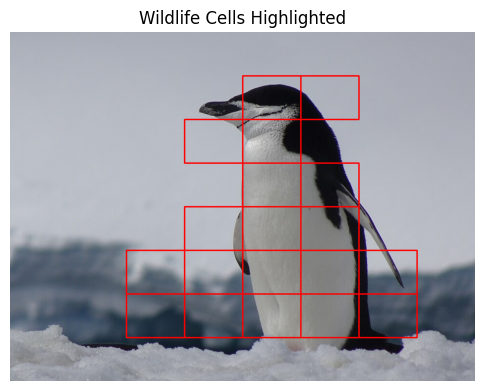

In [50]:
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import joblib
# The actual feature extraction function is defined in a previous cell and is directly accessible.
# No import statement is needed for functions defined within the same Colab notebook.

# ---------- CONFIG ----------
BEST_MODEL_PKL = "wildlife_model.pkl"
SCALER_PKL = "scaler.pkl"
PCA_PKL = "pca.pkl"
GRID_SIZE = (8, 8)  # same as training

# Load trained objects
best_model = joblib.load(BEST_MODEL_PKL)
scaler = joblib.load(SCALER_PKL)
pca = joblib.load(PCA_PKL)

# ---------- Utility Functions ----------
def split_into_grid_cells(img, grid_size):
    """Split image into grid cells (returns list of cells and their positions)."""
    h, w = img.shape[:2]
    cell_h, cell_w = h // grid_size[0], w // grid_size[1]
    cells = []
    positions = []
    for i in range(grid_size[0]):
        for j in range(grid_size[1]):
            cell = img[i*cell_h:(i+1)*cell_h, j*cell_w:(j+1)*cell_w]
            cells.append(cell)
            positions.append((i, j))
    return cells, positions

# ---------- Test on New Image ----------
def test_new_image(image_path, output_csv_path=None, visualize=True):
    img = cv2.imread(image_path)
    if img is None:
        print(f"Error: Image not found or unreadable at {image_path}")
        return

    cells, positions = split_into_grid_cells(img, GRID_SIZE)
    X = []
    for idx, cell in enumerate(cells):
        features = extract_all_cell_features(cell, positions[idx][0], positions[idx][1], GRID_SIZE)
        X.append(features)
    X = np.array(X)

    # Scale + PCA
    X_scaled = scaler.transform(X)
    X_pca = pca.transform(X_scaled)

    # Predict
    y_pred = best_model.predict(X_pca)

    # ---------- Save CSV ----------
    if output_csv_path:
        df_out = pd.DataFrame({
            "cell_number": list(range(len(cells))),
            "predicted_label": y_pred
        })
        df_out.to_csv(output_csv_path, index=False)
        print(f"✅ Predictions saved to {output_csv_path}")

    # ---------- Visualization ----------
    if visualize:
        img_vis = img.copy()
        h, w = img.shape[:2]
        cell_h, cell_w = h // GRID_SIZE[0], w // GRID_SIZE[1]

        for idx, label in enumerate(y_pred):
            if label == 1:
                i, j = positions[idx]
                cv2.rectangle(img_vis,
                              (j*cell_w, i*cell_h),
                              ((j+1)*cell_w, (i+1)*cell_h),
                              color=(0,0,255), thickness=2)

        plt.figure(figsize=(6,6))
        plt.imshow(cv2.cvtColor(img_vis, cv2.COLOR_BGR2RGB))
        plt.title("Wildlife Cells Highlighted")
        plt.axis("off")
        plt.show()

# ---------- Example Usage ----------
test_new_image("/content/Penguin.jpg", output_csv_path="/content/new_image_predictions2.csv")